In [19]:
import ROOT as r
import uproot
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import ks_2samp, chi2 as chi2_dist

# Check statistics of detector variations in cross section variables

In [20]:
fin = uproot.open("/exp/icarus/data/users/micarrig/merged_v27p2_fixed.root")

In [21]:
e_bins = [300, 390, 490, 600, 730, 870, 1030, 1240, 1500, 2000, 5000]

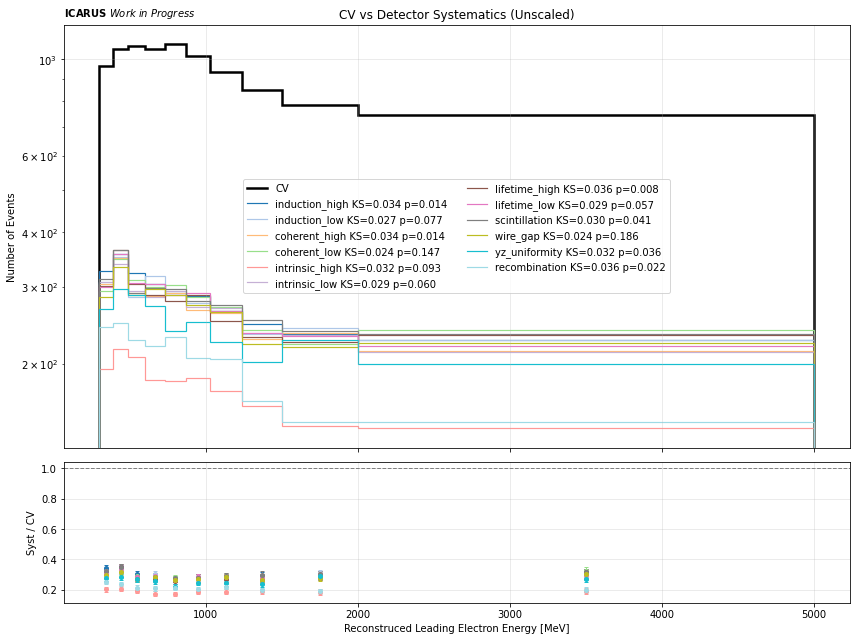

In [51]:
var = 'reco_leading_electron_energy'
samples = ['induction_high', 'induction_low', 'coherent_high', 'coherent_low', 'intrinsic_high', 'intrinsic_low',
           'lifetime_high', 'lifetime_low', 'scintillation', 'wire_gap', 'yz_uniformity', 'recombination']

e_cv = fin[f'events/NuMIFull/selected'].arrays([var, 'true_category'], library='np')
a_cv = np.asarray(e_cv[var][e_cv['true_category'] == 0])
cv_e = a_cv[np.isfinite(a_cv)]

e_bins_arr = np.array(e_bins)
bin_centers = (e_bins_arr[:-1] + e_bins_arr[1:]) / 2
counts_cv, _ = np.histogram(a_cv, bins=e_bins_arr)

fig, ax = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax[0].stairs(counts_cv, e_bins_arr, label='CV', color='black', linewidth=2.5)

colors = plt.cm.tab20(np.linspace(0, 1, len(samples)))

for i, sample in enumerate(samples):
    color = colors[i]

    e_sel = fin[f'events/{sample}/selected'].arrays([var, 'true_category'], library='np')
    a_sel = np.asarray(e_sel[var][e_sel['true_category'] == 0])
    sel_e = a_sel[np.isfinite(a_sel)]

    counts_sel, _ = np.histogram(a_sel, bins=e_bins_arr)

    ks_res = ks_2samp(cv_e, sel_e, alternative='two-sided', method='auto')

    mask = counts_cv > 0
    ndof = int(mask.sum())
    chi2_val = float(np.sum((counts_sel[mask] - counts_cv[mask])**2 / counts_cv[mask]))
    p_chi2 = float(chi2_dist.sf(chi2_val, ndof))

    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(counts_cv > 0, counts_sel / counts_cv, np.nan)
        ratio_err = np.where(
            (counts_cv > 0) & (counts_sel > 0),
            ratio * np.sqrt(1.0 / counts_sel + 1.0 / counts_cv),
            np.nan
        )

    label = f'{sample} KS={ks_res.statistic:.3f} p={ks_res.pvalue:.3f}' #  χ²/ndf={chi2_val:.2f}/{ndof:.2f}={chi2_val/ndof:.2f}'
    ax[0].stairs(counts_sel, e_bins_arr, color=color, linewidth=1.2, label=label)
    ax[1].errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color=color,
                   markersize=4, linewidth=1, capsize=2)

ax[0].legend(ncol=2, fontsize=10, loc='best', framealpha=0.8)
ax[0].set_ylabel('Number of Events')
ax[0].set_title(f'CV vs Detector Systematics (Unscaled)')
ax[0].grid(alpha=0.3)
ax[0].set_yscale('log')

ax[1].axhline(1, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(f'Reconstruced Leading Electron Energy [MeV]')
ax[1].set_ylabel('Syst / CV')
# ax[1].set_ylim(0.5, 1.5)
ax[1].grid(alpha=0.3)

ax[0].text(0, 1.01, r'$\bf{ICARUS}$ Work in Progress', transform=ax[0].transAxes,
        ha='left', va='bottom', fontsize=10, style='italic')
# ax[0].text(1, 1.01, 'POT=2.5e20', transform=ax.transAxes,
#         ha='right', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

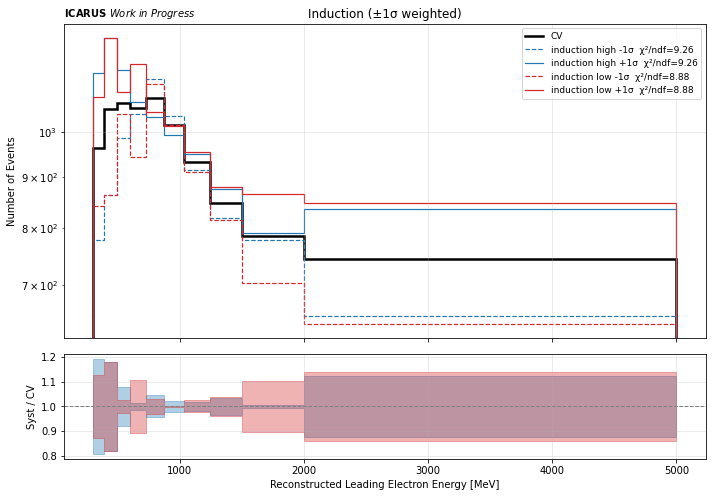

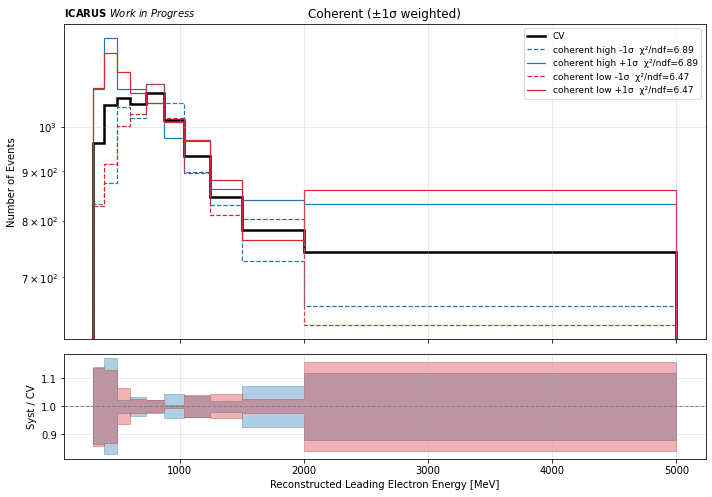

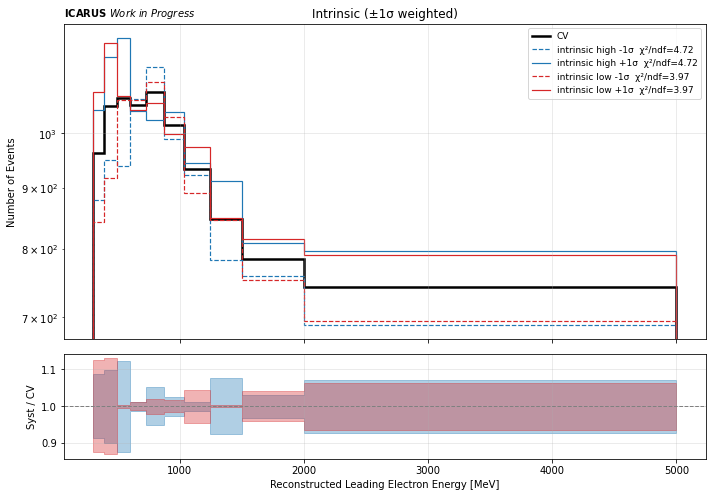

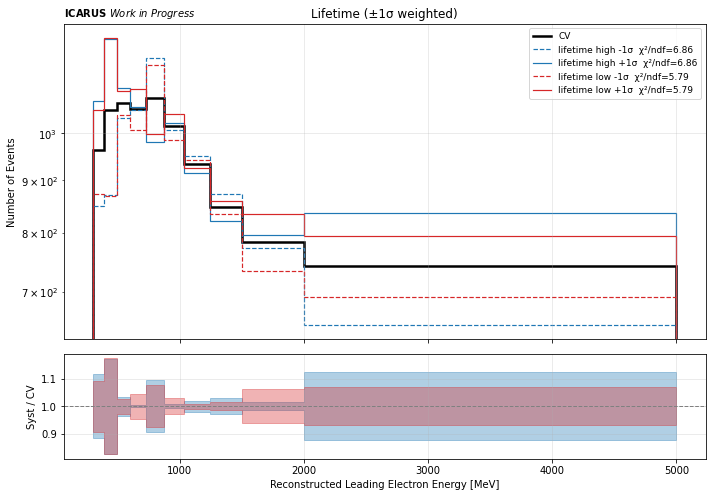

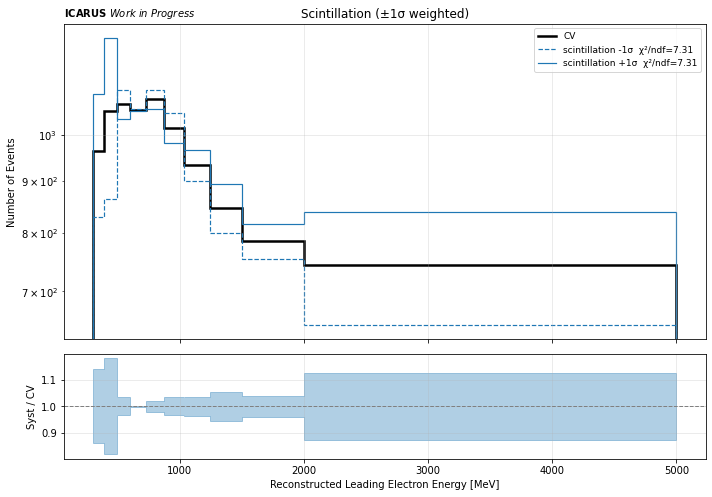

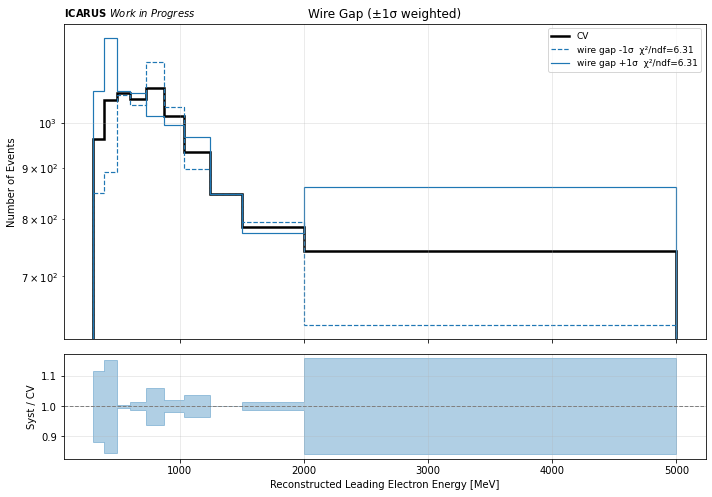

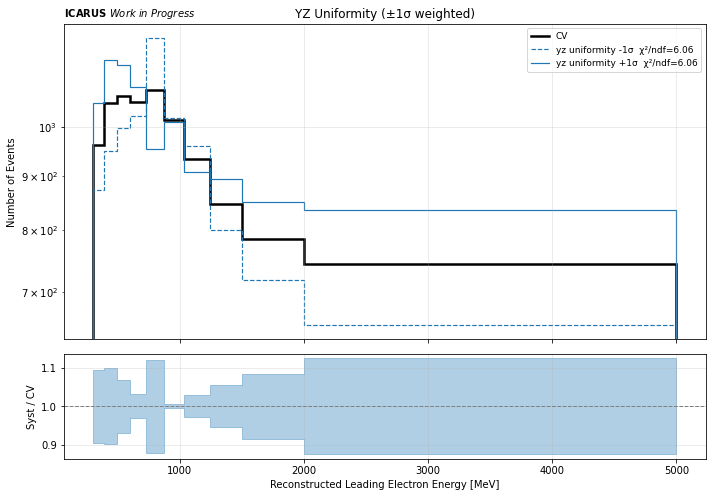

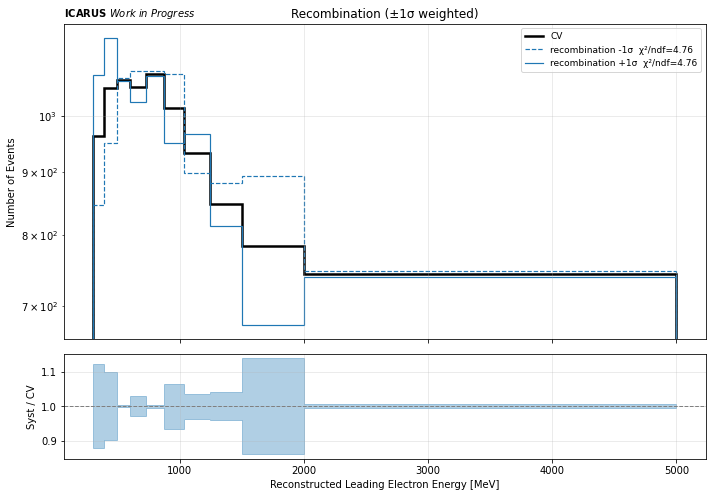

In [55]:
var = 'reco_leading_electron_energy'

e_cv = fin[f'events/NuMIFull/selected'].arrays([var, 'true_category'], library='np')
a_cv = np.asarray(e_cv[var][e_cv['true_category'] == 0])

e_bins_arr = np.array(e_bins)
counts_cv, _ = np.histogram(a_cv, bins=e_bins_arr)

sample_groups = [
    ('Induction',     ['induction_high',  'induction_low']),
    ('Coherent',      ['coherent_high',   'coherent_low']),
    ('Intrinsic',     ['intrinsic_high',  'intrinsic_low']),
    ('Lifetime',      ['lifetime_high',   'lifetime_low']),
    ('Scintillation', ['scintillation']),
    ('Wire Gap',      ['wire_gap']),
    ('YZ Uniformity', ['yz_uniformity']),
    ('Recombination', ['recombination']),
]

all_samples = [s for _, grp in sample_groups for s in grp]
e_sel = fin[f'events/NuMIFull/selected_variationTree'].arrays(all_samples, library='np')

pair_colors = ['tab:blue', 'tab:red']

for group_name, group_samples in sample_groups:
    fig, ax = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    ax[0].stairs(counts_cv, e_bins_arr, label='CV', color='black', linewidth=2.5)

    mask = counts_cv > 0
    ndof = int(mask.sum())

    for j, sample in enumerate(group_samples):
        color = pair_colors[j]
        base = sample.replace('_', ' ')

        w_all = np.asarray(e_sel[sample][e_cv['true_category'] == 0])
        w_minus = [x[2] for x in w_all]
        w_plus  = [x[4] for x in w_all]

        counts_minus, _ = np.histogram(a_cv, bins=e_bins_arr, weights=w_minus)
        counts_plus,  _ = np.histogram(a_cv, bins=e_bins_arr, weights=w_plus)

        chi2_minus = float(np.sum((counts_minus[mask] - counts_cv[mask])**2 / counts_cv[mask]))
        chi2_plus  = float(np.sum((counts_plus[mask]  - counts_cv[mask])**2 / counts_cv[mask]))

        with np.errstate(invalid='ignore', divide='ignore'):
            ratio_minus = np.where(counts_cv > 0, counts_minus / counts_cv, np.nan)
            ratio_plus  = np.where(counts_cv > 0, counts_plus  / counts_cv, np.nan)

        label_minus = f'{base} -1σ  χ²/ndf={chi2_minus/ndof:.2f}'
        label_plus  = f'{base} +1σ  χ²/ndf={chi2_plus/ndof:.2f}'

        ax[0].stairs(counts_minus, e_bins_arr, color=color, linewidth=1.2, linestyle='--', label=label_minus)
        ax[0].stairs(counts_plus,  e_bins_arr, color=color, linewidth=1.2, linestyle='-',  label=label_plus)
        ax[1].fill_between(e_bins_arr,
                           np.append(ratio_minus, ratio_minus[-1]),
                           np.append(ratio_plus,  ratio_plus[-1]),
                           step='post', alpha=0.35, color=color)

    ax[0].legend(ncol=1, fontsize=9, loc='best', framealpha=0.8)
    ax[0].set_ylabel('Number of Events')
    ax[0].set_title(f'{group_name} (±1σ weighted)')
    ax[0].grid(alpha=0.3)
    ax[0].set_yscale('log')

    ax[1].axhline(1, color='gray', linestyle='--', linewidth=1)
    ax[1].set_xlabel('Reconstructed Leading Electron Energy [MeV]')
    ax[1].set_ylabel('Syst / CV')
    ax[1].grid(alpha=0.3)

    ax[0].text(0, 1.01, r'$\bf{ICARUS}$ Work in Progress', transform=ax[0].transAxes,
               ha='left', va='bottom', fontsize=10, style='italic')

    plt.tight_layout()
    plt.show()


KS statistic D = 0.981706
p-value       = 0
Reject H0 at alpha=0.05: the two samples are not consistent with the same parent distribution.
